# P04: Swap the Dynamics Backbone

Replace the P02 RSSM with a causal Transformer and compare both backbones on the same synthetic data. The tutorial focuses on the engineering tradeoff: a stronger inductive bias in RSSM versus the easier parallelization and longer-context flexibility of attention. The pipeline is CatVAE tokenization, causal Transformer training, and a rollout comparison against RSSM, read as a controlled comparison, not a general claim that the Transformer is better.

**Prerequisite**: P02 (`rssm.pt`) if present; otherwise the rollout comparison falls back to a randomly initialized RSSM so the notebook still runs, but the RSSM-vs-Transformer numbers are only meaningful with the pretrained checkpoint. This notebook trains a CatVAE and Transformer from scratch and saves them to `transformer_wm.pt` for P05.

> Notebook source: [p04_transformer_backbone.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/en/projects/p04_transformer_backbone.ipynb)

In [1]:
%%bash
# Install dependencies for a fresh environment.
if command -v rocm-smi >/dev/null || [ -d /opt/rocm ]; then
  pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.2
  pip install matplotlib numpy
else
  pip install torch torchvision matplotlib numpy
fi


With dependencies installed, import the core libraries and configure the shared runtime for both the VAE and Transformer sections.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt
import time
import math
from pathlib import Path

torch.manual_seed(42)
np.random.seed(42)
try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'
IS_ROCM = USE_CUDA and torch.version.hip is not None
LOAD_DEVICE = torch.device('cpu') if USE_TPU else DEVICE


def _is_rocm_radeon():
    if not IS_ROCM:
        return False
    try:
        arch = torch.cuda.get_device_properties(0).gcnArchName.split(':')[0]
    except Exception:
        return False
    return arch.startswith(('gfx10', 'gfx11', 'gfx12'))


# Fall back to the math SDPA backend only on Radeon.
IS_ROCM_RADEON = _is_rocm_radeon()
if IS_ROCM_RADEON:
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)
    torch.backends.cuda.enable_math_sdp(True)
    print('ROCm Radeon (RDNA) detected: using math SDPA backend to avoid NaN.')


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

PATH = Path('.')
print('Device:', DEVICE)
if USE_TPU:
    print('TPU backend    : torch_xla')
print('PyTorch version:', torch.__version__)

Device: cuda
PyTorch version: 2.11.0+cu128


## 1. Categorical VAE

Tokenize each frame into a single 32-dimensional discrete code.

Generating 1000 synthetic shape images...
Image tensor shape: torch.Size([1000, 3, 64, 64])   dtype: torch.float32


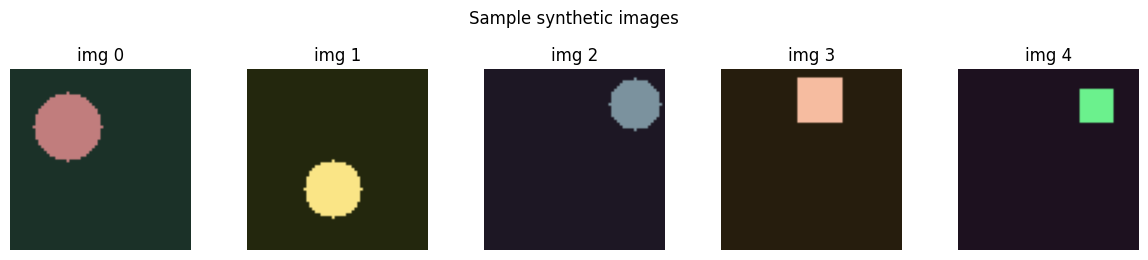

In [3]:
# Synthetic shape image dataset.
def make_shape_images(n=1000, size=64, seed=0):
    rng = np.random.RandomState(seed)
    imgs = np.zeros((n, 3, size, size), dtype=np.float32)
    for i in range(n):
        # Background
        bg = rng.uniform(0.05, 0.2, (3, 1, 1)).astype(np.float32)
        imgs[i] = bg
        # Random shape: circle or rectangle
        color = rng.uniform(0.4, 1.0, 3).astype(np.float32)
        cx = rng.randint(10, size - 10)
        cy = rng.randint(10, size - 10)
        r = rng.randint(5, 14)
        shape_type = rng.randint(0, 2)
        for c in range(3):
            if shape_type == 0:  # circle
                for y in range(size):
                    for x in range(size):
                        if (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2:
                            imgs[i, c, y, x] = color[c]
            else:  # rectangle
                x0, x1 = max(0, cx - r), min(size, cx + r)
                y0, y1 = max(0, cy - r), min(size, cy + r)
                imgs[i, c, y0:y1, x0:x1] = color[c]
    return torch.from_numpy(imgs)

print('Generating 1000 synthetic shape images...')
images = make_shape_images(n=1000, size=64, seed=42)
print('Image tensor shape:', images.shape, '  dtype:', images.dtype)

# Quick sanity check
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(images[i].permute(1, 2, 0).numpy())
    ax.axis('off')
    ax.set_title(f'img {i}')
plt.suptitle('Sample synthetic images', y=1.02)
plt.tight_layout()
plt.show()

Once the synthetic shape dataset is ready, define the straight-through Gumbel-softmax path that makes the categorical VAE trainable end to end.

In [4]:
# Straight-through Gumbel-softmax.
def straight_through_gumbel(logits, tau=1.0):
    """Returns a straight-through estimator for discrete sampling."""
    y_soft = F.gumbel_softmax(logits, tau=tau, hard=False)
    y_hard = F.one_hot(y_soft.argmax(-1), num_classes=logits.shape[-1]).float()
    # Straight-through: forward uses y_hard, backward flows through y_soft
    return (y_hard - y_soft).detach() + y_soft


# --- Categorical VAE ---
NUM_CATEGORIES = 32   # discrete vocabulary size
Z_DIM = 32            # embedding dimension per token

class CatVAEEncoder(nn.Module):
    """CNN that maps a 3x64x64 frame to logits over NUM_CATEGORIES."""
    def __init__(self, num_categories=NUM_CATEGORIES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# 4x4
            nn.ReLU(),
            nn.Flatten(),                 # 256*4*4 = 4096
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_categories),
        )

    def forward(self, x):
        return self.net(x)  # (B, num_categories)


class CatVAEDecoder(nn.Module):
    """MLP + ConvTranspose that maps a 32-dim one-hot embedding back to 3x64x64."""
    def __init__(self, num_categories=NUM_CATEGORIES):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(num_categories, 256),
            nn.ReLU(),
            nn.Linear(256, 256 * 4 * 4),
            nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),     # 64x64
            nn.Sigmoid(),
        )

    def forward(self, z_onehot):
        h = self.fc(z_onehot)
        h = h.view(-1, 256, 4, 4)
        return self.deconv(h)  # (B, 3, 64, 64)


class CatVAE(nn.Module):
    def __init__(self, num_categories=NUM_CATEGORIES, tau=1.0):
        super().__init__()
        self.encoder = CatVAEEncoder(num_categories)
        self.decoder = CatVAEDecoder(num_categories)
        self.tau = tau

    def encode(self, x):
        """Returns straight-through one-hot and argmax indices."""
        logits = self.encoder(x)           # (B, K)
        z = straight_through_gumbel(logits, tau=self.tau)  # (B, K)
        idx = logits.argmax(-1)            # (B,)
        return z, idx, logits

    def forward(self, x):
        z, idx, logits = self.encode(x)
        recon = self.decoder(z)
        return recon, z, idx, logits

catvae = CatVAE(num_categories=NUM_CATEGORIES, tau=1.0).to(DEVICE)
total_params = sum(p.numel() for p in catvae.parameters())
print(f'CatVAE parameters: {total_params:,}')

CatVAE parameters: 3,498,211


With the relaxation in place, train CatVAE on the synthetic images and let the discrete latent code learn a compact representation.

Training CatVAE...
  Epoch  10/30  recon_loss=0.0265
  Epoch  20/30  recon_loss=0.0260
  Epoch  30/30  recon_loss=0.0259
CatVAE training complete.


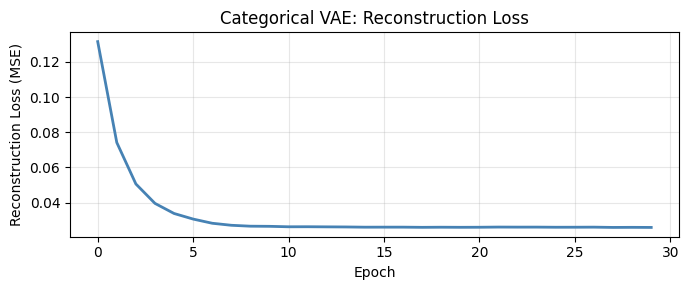

In [5]:
# Train CatVAE.
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(images)
loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0 if USE_TPU else 2, pin_memory=USE_CUDA)

opt_vae = torch.optim.Adam(catvae.parameters(), lr=3e-4)

VAE_EPOCHS = 30
vae_losses = []

print('Training CatVAE...')
for epoch in range(VAE_EPOCHS):
    epoch_loss = 0.0
    for (batch,) in loader:
        batch = batch.to(DEVICE)
        recon, z, idx, logits = catvae(batch)
        # Reconstruction loss
        recon_loss = F.mse_loss(recon, batch)
        # Entropy regularization: encourage uniform category use
        probs = F.softmax(logits, dim=-1).mean(0)  # (K,)
        entropy_reg = (probs * (probs + 1e-8).log()).sum()  # negative entropy
        loss = recon_loss + 0.01 * entropy_reg
        opt_vae.zero_grad()
        loss.backward()
        optimizer_step(opt_vae)
        epoch_loss += recon_loss.item()
    vae_losses.append(epoch_loss / len(loader))
    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:3d}/{VAE_EPOCHS}  recon_loss={vae_losses[-1]:.4f}')

print('CatVAE training complete.')

plt.figure(figsize=(7, 3))
plt.plot(vae_losses, linewidth=2, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (MSE)')
plt.title('Categorical VAE: Reconstruction Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

After training starts, add a quick reconstruction check to verify that the categorical bottleneck still preserves image structure.

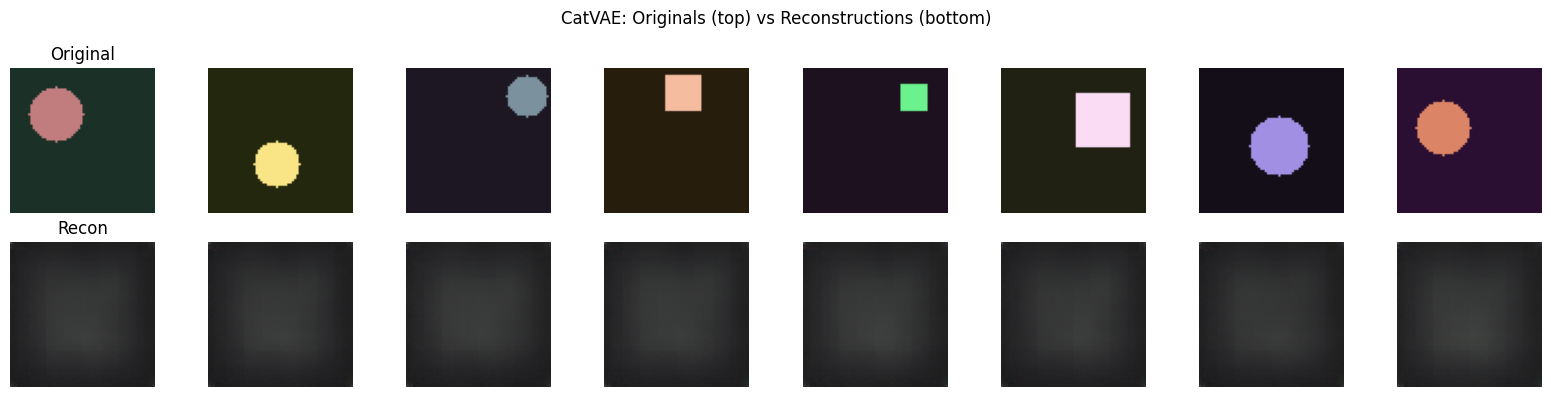

CatVAE(
  (encoder): CatVAEEncoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=4096, out_features=256, bias=True)
      (10): ReLU()
      (11): Linear(in_features=256, out_features=32, bias=True)
    )
  )
  (decoder): CatVAEDecoder(
    (fc): Sequential(
      (0): Linear(in_features=32, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=4096, bias=True)
      (3): ReLU()
    )
    (deconv): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
     

In [6]:
# Visual check of CatVAE reconstructions.
catvae.eval()
with torch.no_grad():
    sample = images[:8].to(DEVICE)
    recon, _, _, _ = catvae(sample)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(sample[i].cpu().permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[0, i].set_title('Original' if i == 0 else '')
    axes[1, i].imshow(recon[i].cpu().permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
    axes[1, i].set_title('Recon' if i == 0 else '')
plt.suptitle('CatVAE: Originals (top) vs Reconstructions (bottom)')
plt.tight_layout()
plt.show()
catvae.train()

## 2. Causal Transformer

Predict future tokens and rewards with causal attention.

The world model Transformer operates on a sequence of interleaved (z, a) tokens. At each step t:
- z_t is the CatVAE encoding of the observation at step t (32-dim one-hot)
- a_t is an action embedding (2 discrete actions, projected to 32-dim)

Causal masking ensures position t can only attend to positions up to and including t, so the model cannot peek at future observations during training.

The output at position t predicts: the next latent token z_{t+1} (cross-entropy), the reward r_t (MSE), and the done flag d_t (BCE).

In [7]:
# Causal Transformer world model.
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 2
SEQ_LEN = 20   # trajectory length
N_ACTIONS = 2


class CausalTransformerWM(nn.Module):
    def __init__(self, num_categories=NUM_CATEGORIES, d_model=D_MODEL,
                 n_heads=N_HEADS, n_layers=N_LAYERS, n_actions=N_ACTIONS,
                 max_len=SEQ_LEN):
        super().__init__()
        self.d_model = d_model
        self.num_categories = num_categories

        # Project z (one-hot) and action to d_model
        self.z_proj = nn.Linear(num_categories, d_model)
        self.a_embed = nn.Embedding(n_actions, d_model)

        # Positional encoding
        pos = torch.arange(max_len * 2).unsqueeze(1)  # *2 for (z,a) interleaved
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len * 2, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)

        # Transformer layers using nn.MultiheadAttention
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads,
                dim_feedforward=d_model * 4,
                batch_first=True, norm_first=True
            )
            for _ in range(n_layers)
        ])

        # Output heads
        self.token_head = nn.Linear(d_model, num_categories)   # next-token prediction
        self.reward_head = nn.Linear(d_model, 1)               # reward regression
        self.done_head = nn.Linear(d_model, 1)                 # done classification

    def _causal_mask(self, T):
        """Upper-triangular mask: True means 'ignore this position'."""
        return torch.triu(torch.ones(T, T, device=self.pe.device), diagonal=1).bool()

    def forward(self, z_seq, a_seq):
        """
        z_seq: (B, T, num_categories)  one-hot latents
        a_seq: (B, T)                  integer actions
        Returns:
          token_logits: (B, T, num_categories)
          reward_pred:  (B, T, 1)
          done_pred:    (B, T, 1)
        """
        B, T, _ = z_seq.shape

        z_emb = self.z_proj(z_seq)          # (B, T, D)
        a_emb = self.a_embed(a_seq)         # (B, T, D)

        # Interleave z and a tokens: [z0, a0, z1, a1, ...] -> length 2T
        tokens = torch.stack([z_emb, a_emb], dim=2).view(B, 2 * T, self.d_model)
        tokens = tokens + self.pe[:2 * T].unsqueeze(0)

        mask = self._causal_mask(2 * T)
        h = tokens
        for layer in self.layers:
            h = layer(h, src_mask=mask, is_causal=False)

        # Extract z positions (even indices) for prediction heads
        z_h = h[:, 0::2, :]   # (B, T, D)  -- output at each z position

        token_logits = self.token_head(z_h)   # (B, T, K)
        reward_pred  = self.reward_head(z_h)  # (B, T, 1)
        done_pred    = self.done_head(z_h)    # (B, T, 1)
        return token_logits, reward_pred, done_pred


transformer_wm = CausalTransformerWM().to(DEVICE)
total_params_t = sum(p.numel() for p in transformer_wm.parameters())
print(f'Causal Transformer parameters: {total_params_t:,}')

Causal Transformer parameters: 405,410


## 3. Training

We generate the same synthetic trajectory data as P02: 200 trajectories of 20 steps each, using a two-action environment where the agent pushes a shape across the frame. All observations are encoded with the CatVAE before training the Transformer.

In [8]:
# Synthetic trajectory data.
def make_obs(cx, cy, size=64):
    img = np.zeros((3, size, size), dtype=np.float32)
    r = 8
    color = np.array([0.9, 0.3, 0.3], dtype=np.float32)
    for y in range(size):
        for x in range(size):
            if (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2:
                img[:, y, x] = color
    return img


def generate_trajectories(n_traj=200, horizon=20, size=64, seed=0):
    rng = np.random.RandomState(seed)
    obs_list, act_list, rew_list, done_list = [], [], [], []
    for _ in range(n_traj):
        cx = rng.randint(20, size - 20)
        cy = rng.randint(20, size - 20)
        traj_obs, traj_act, traj_rew, traj_done = [], [], [], []
        for t in range(horizon):
            traj_obs.append(make_obs(cx, cy, size))
            action = rng.randint(0, 2)
            traj_act.append(action)
            # Action 0: move right, Action 1: move left
            cx = np.clip(cx + (4 if action == 0 else -4), 10, size - 10)
            rew = 1.0 if cx > size // 2 else 0.0
            traj_rew.append(rew)
            traj_done.append(0.0)
        obs_list.append(traj_obs)
        act_list.append(traj_act)
        rew_list.append(traj_rew)
        done_list.append(traj_done)
    obs_arr  = torch.tensor(np.array(obs_list),  dtype=torch.float32)   # (N, T, 3, 64, 64)
    act_arr  = torch.tensor(np.array(act_list),  dtype=torch.long)       # (N, T)
    rew_arr  = torch.tensor(np.array(rew_list),  dtype=torch.float32)   # (N, T)
    done_arr = torch.tensor(np.array(done_list), dtype=torch.float32)   # (N, T)
    return obs_arr, act_arr, rew_arr, done_arr


print('Generating 200 synthetic trajectories (20 steps each)...')
obs_arr, act_arr, rew_arr, done_arr = generate_trajectories(n_traj=200, horizon=SEQ_LEN)
print(f'obs: {obs_arr.shape}, act: {act_arr.shape}, rew: {rew_arr.shape}')

Generating 200 synthetic trajectories (20 steps each)...
obs: torch.Size([200, 20, 3, 64, 64]), act: torch.Size([200, 20]), rew: torch.Size([200, 20])


With the image side finished, switch to trajectories so the Transformer world model has temporal data to learn from.

In [9]:
# Encode all observations with CatVAE.
catvae.eval()
N, T, C, H, W = obs_arr.shape
z_encoded = torch.zeros(N, T, NUM_CATEGORIES)  # one-hot tokens

with torch.no_grad():
    flat_obs = obs_arr.view(N * T, C, H, W).to(DEVICE)
    logits_all = catvae.encoder(flat_obs)                              # (N*T, K)
    idx_all = logits_all.argmax(-1)                                    # (N*T,)
    z_onehot_all = F.one_hot(idx_all, num_classes=NUM_CATEGORIES).float()  # (N*T, K)
    z_encoded = z_onehot_all.view(N, T, NUM_CATEGORIES).cpu()

print('Encoded latents shape:', z_encoded.shape)
unique_tokens = idx_all.unique().numel()
print(f'Unique token categories used: {unique_tokens} / {NUM_CATEGORIES}')
catvae.train()

Encoded latents shape: torch.Size([200, 20, 32])
Unique token categories used: 3 / 32


CatVAE(
  (encoder): CatVAEEncoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=4096, out_features=256, bias=True)
      (10): ReLU()
      (11): Linear(in_features=256, out_features=32, bias=True)
    )
  )
  (decoder): CatVAEDecoder(
    (fc): Sequential(
      (0): Linear(in_features=32, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=4096, bias=True)
      (3): ReLU()
    )
    (deconv): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
     

Once observations are tokenized, the Transformer can model temporal dynamics directly over the latent sequence.

In [10]:
# Train the Causal Transformer.
from torch.utils.data import TensorDataset, DataLoader

traj_dataset = TensorDataset(z_encoded, act_arr, rew_arr, done_arr)
traj_loader  = DataLoader(traj_dataset, batch_size=32, shuffle=True)

opt_t = torch.optim.Adam(transformer_wm.parameters(), lr=1e-3)

TRANS_EPOCHS = 20
token_losses, reward_losses = [], []
epoch_times = []   # wall-clock seconds per epoch

print('Training Causal Transformer...')
for epoch in range(TRANS_EPOCHS):
    t0 = time.time()
    ep_tok, ep_rew = 0.0, 0.0
    for z_b, a_b, r_b, d_b in traj_loader:
        z_b = z_b.to(DEVICE)
        a_b = a_b.to(DEVICE)
        r_b = r_b.to(DEVICE)
        d_b = d_b.to(DEVICE)

        # Predict: at position t, predict token t+1, reward t, done t
        token_logits, reward_pred, done_pred = transformer_wm(z_b, a_b)  # (B, T, K/1/1)

        # Next-token labels: shift by 1, ignore last position
        target_idx = z_b[:, 1:, :].argmax(-1)           # (B, T-1)
        pred_logits = token_logits[:, :-1, :]            # (B, T-1, K)
        tok_loss = F.cross_entropy(
            pred_logits.reshape(-1, NUM_CATEGORIES),
            target_idx.reshape(-1)
        )

        # Reward prediction at all positions
        rew_loss = F.mse_loss(reward_pred.squeeze(-1), r_b)

        # Done prediction
        done_loss = F.binary_cross_entropy_with_logits(done_pred.squeeze(-1), d_b)

        loss = tok_loss + 0.5 * rew_loss + 0.1 * done_loss
        opt_t.zero_grad()
        loss.backward()
        # On ROCm Radeon (RDNA), skip non-finite gradients so they cannot corrupt the weights
        grads_finite = (not IS_ROCM_RADEON) or all(
            p.grad is None or torch.isfinite(p.grad).all()
            for p in transformer_wm.parameters())
        if grads_finite:
            nn.utils.clip_grad_norm_(transformer_wm.parameters(), 1.0)
            opt_t.step()

        ep_tok += tok_loss.item()
        ep_rew += rew_loss.item()

    elapsed = time.time() - t0
    epoch_times.append(elapsed)
    token_losses.append(ep_tok / len(traj_loader))
    reward_losses.append(ep_rew / len(traj_loader))
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:2d}/{TRANS_EPOCHS}  '
              f'tok_loss={token_losses[-1]:.4f}  '
              f'rew_loss={reward_losses[-1]:.4f}  '
              f'time={elapsed:.2f}s')

print('Transformer training complete.')

Training Causal Transformer...
  Epoch  5/20  tok_loss=0.3347  rew_loss=0.1749  time=0.06s
  Epoch 10/20  tok_loss=0.3059  rew_loss=0.1794  time=0.06s
  Epoch 15/20  tok_loss=0.2895  rew_loss=0.2807  time=0.06s
  Epoch 20/20  tok_loss=0.2559  rew_loss=0.1979  time=0.06s
Transformer training complete.


Now that optimization is underway, track token loss and reward loss together so both prediction heads stay in view.

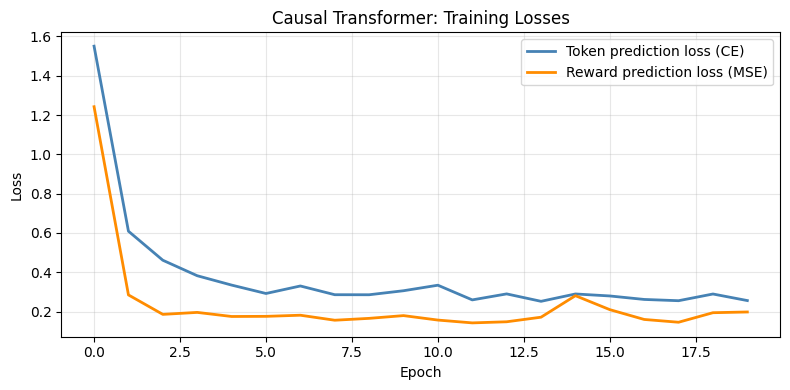

In [11]:
# --- Plot token and reward losses ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(token_losses,  label='Token prediction loss (CE)',  color='steelblue',  linewidth=2)
ax.plot(reward_losses, label='Reward prediction loss (MSE)', color='darkorange', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Causal Transformer: Training Losses')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Rollout Quality Comparison

Decode rollouts from both backbones and compare image quality across horizons.

We compare imagined rollouts from the RSSM (P02) and the Causal Transformer. If `rssm.pt` exists from P02 we load it; otherwise we initialize an RSSM with the same random seed used in P02. Both models generate 10-step rollouts from the same starting state, and we decode the predicted latents back to pixels using the CatVAE decoder. PSNR measures pixel-level fidelity at each horizon step.

In [12]:
# PSNR utility.
def psnr(pred, target):
    mse = F.mse_loss(pred, target)
    return 10 * torch.log10(1.0 / (mse + 1e-8))


# P02-compatible RSSM so the saved checkpoint can load cleanly here.
class RSSM(nn.Module):
    def __init__(self, latent_dim=32, action_dim=1, hidden_dim=128):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.action_dim = action_dim

        self.gru = nn.GRUCell(latent_dim + action_dim, hidden_dim)
        self.prior_net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )
        self.post_net = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )
        self.recon = nn.Linear(latent_dim, latent_dim)

    def _rsample(self, mu, logvar):
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)

    def prior_step(self, z, h, a):
        if a.dim() == 1:
            a = a.unsqueeze(-1)
        h = self.gru(torch.cat([z, a.float()], dim=-1), h)
        pr = self.prior_net(h)
        mu, _ = pr.chunk(2, dim=-1)
        return mu, h

    def posterior_step(self, h, a, z_obs):
        if a.dim() == 1:
            a = a.unsqueeze(-1)
        po = self.post_net(torch.cat([h, z_obs], dim=-1))
        mu, logvar = po.chunk(2, dim=-1)
        z = self._rsample(mu, logvar)
        h = self.gru(torch.cat([z, a.float()], dim=-1), h)
        return z, h


# --- Load or initialize RSSM ---
rssm_path = next((p for p in [PATH / 'rssm.pt', PATH / 'notebooks' / 'rssm.pt'] if p.exists()), None)
if rssm_path is not None:
    try:
        state = torch.load(rssm_path, map_location=DEVICE)
        if isinstance(state, dict) and 'rssm_state_dict' in state:
            rssm = RSSM(
                latent_dim=int(state.get('latent_dim', 32)),
                action_dim=int(state.get('action_dim', 1)),
                hidden_dim=int(state.get('hidden_dim', 128)),
            ).to(DEVICE)
            rssm.load_state_dict(state['rssm_state_dict'])
            print(
                f"Loaded RSSM weights from {rssm_path} "
                f"(hidden_dim={rssm.hidden_dim}, latent_dim={rssm.latent_dim}, action_dim={rssm.action_dim})"
            )
        elif isinstance(state, dict) and 'rssm' in state:
            rssm = RSSM().to(DEVICE)
            rssm.load_state_dict(state['rssm'])
            print(f'Loaded RSSM weights from {rssm_path} (legacy rssm key)')
        else:
            rssm = RSSM().to(DEVICE)
            rssm.load_state_dict(state)
            print(f'Loaded RSSM weights from {rssm_path} (raw state_dict)')
    except Exception as e:
        rssm = RSSM().to(DEVICE)
        print(f'Could not load rssm.pt ({e}). Using randomly initialized RSSM.')
else:
    rssm = RSSM().to(DEVICE)
    print('rssm.pt not found. Using randomly initialized RSSM (P02 baseline).')

rssm.eval()
transformer_wm.eval()
catvae.eval()

Loaded RSSM weights from rssm.pt (hidden_dim=128, latent_dim=32, action_dim=1)


CatVAE(
  (encoder): CatVAEEncoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
      (9): Linear(in_features=4096, out_features=256, bias=True)
      (10): ReLU()
      (11): Linear(in_features=256, out_features=32, bias=True)
    )
  )
  (decoder): CatVAEDecoder(
    (fc): Sequential(
      (0): Linear(in_features=32, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=4096, bias=True)
      (3): ReLU()
    )
    (deconv): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
     

With the PSNR utility defined, evaluate it across rollout horizons to see how prediction quality decays over time.

In [13]:
# Compute PSNR vs horizon.
ROLLOUT_LEN = 10
N_EVAL = 5  # trajectories to average over

# Use the first N_EVAL trajectories as eval set
eval_obs  = obs_arr[:N_EVAL].to(DEVICE)   # (N_EVAL, T, 3, 64, 64)
eval_act  = act_arr[:N_EVAL].to(DEVICE)   # (N_EVAL, T)
eval_z    = z_encoded[:N_EVAL].to(DEVICE) # (N_EVAL, T, K)

horizons = [1, 3, 5, 10]
psnr_rssm_all  = {h: [] for h in horizons}
psnr_trans_all = {h: [] for h in horizons}

with torch.no_grad():
    for traj_i in range(N_EVAL):
        # Starting state: encode step 0
        z0 = eval_z[traj_i, 0:1]         # (1, K)  one-hot
        acts = eval_act[traj_i]           # (T,)

        # ---- RSSM rollout ----
        z = z0.clone()
        h = torch.zeros(1, rssm.hidden_dim, device=DEVICE)
        rssm_preds = []  # decoded frames at each step
        for t in range(ROLLOUT_LEN):
            a_t = acts[t:t+1].float().unsqueeze(-1)  # (1, 1)
            z, h = rssm.prior_step(z, h, a_t)
            frame = catvae.decoder(z)      # (1, 3, 64, 64)
            rssm_preds.append(frame)

        # ---- Transformer rollout ----
        # Seed with observed z0, then autoregressively predict
        z_seq = z0.unsqueeze(0)            # (1, 1, K)
        trans_preds = []
        for t in range(ROLLOUT_LEN):
            current_len = z_seq.shape[1]
            a_prefix = acts[:current_len].unsqueeze(0)  # (1, current_len)
            tok_logits, _, _ = transformer_wm(z_seq, a_prefix)  # (1, L, K)
            next_logits = tok_logits[:, -1, :]           # (1, K)
            next_z = F.one_hot(next_logits.argmax(-1), num_classes=NUM_CATEGORIES).float()  # (1, K)
            frame = catvae.decoder(next_z)               # (1, 3, 64, 64)
            trans_preds.append(frame)
            z_seq = torch.cat([z_seq, next_z.unsqueeze(1)], dim=1)  # (1, L+1, K)

        # Ground truth frames
        for h in horizons:
            if h <= ROLLOUT_LEN and h < eval_obs.shape[1]:
                gt = eval_obs[traj_i, h:h+1]             # (1, 3, 64, 64)
                p_rssm  = psnr(rssm_preds[h-1],  gt).item()
                p_trans = psnr(trans_preds[h-1], gt).item()
                psnr_rssm_all[h].append(p_rssm)
                psnr_trans_all[h].append(p_trans)

psnr_rssm_mean  = [np.mean(psnr_rssm_all[h])  for h in horizons]
psnr_trans_mean = [np.mean(psnr_trans_all[h]) for h in horizons]

print('PSNR (dB) by horizon step:')
print(f'{"Horizon":>10}  {"RSSM":>10}  {"Transformer":>12}')
for h, r, t in zip(horizons, psnr_rssm_mean, psnr_trans_mean):
    print(f'{h:>10}  {r:>10.2f}  {t:>12.2f}')

PSNR (dB) by horizon step:
   Horizon        RSSM   Transformer
         1       15.59         14.60
         3       18.19         14.62
         5       18.38         14.63
        10       18.36         14.61


After collecting the scores, plot the horizon curve so the overall trend is easier to read.

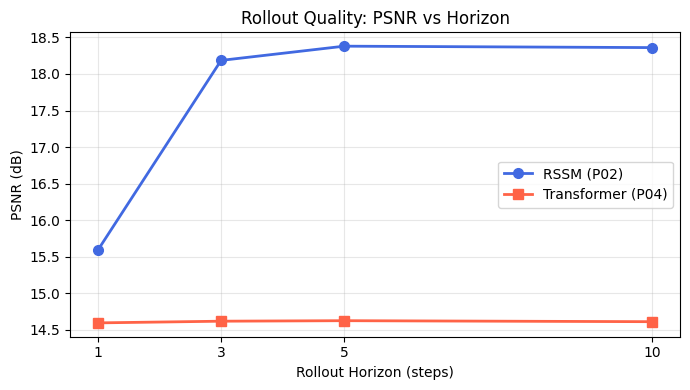

In [14]:
# --- Plot PSNR vs horizon ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(horizons, psnr_rssm_mean,  'o-', color='royalblue',  linewidth=2, label='RSSM (P02)', markersize=7)
ax.plot(horizons, psnr_trans_mean, 's-', color='tomato',     linewidth=2, label='Transformer (P04)', markersize=7)
ax.set_xlabel('Rollout Horizon (steps)')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Rollout Quality: PSNR vs Horizon')
ax.set_xticks(horizons)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The horizon curve shows the aggregate pattern; the image grid makes the step-by-step differences concrete.

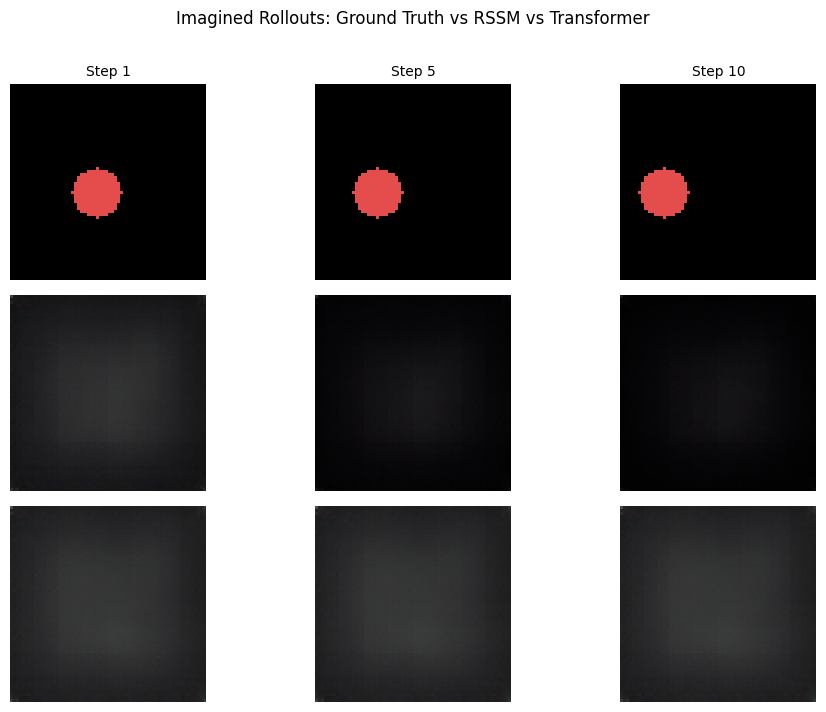

In [15]:
# Image grid: GT / RSSM / Transformer.
display_steps = [1, 5, 10]
traj_i = 0  # use first eval trajectory

with torch.no_grad():
    z0 = eval_z[traj_i, 0:1].to(DEVICE)
    acts = eval_act[traj_i].to(DEVICE)

    # RSSM rollout
    z = z0.clone()
    h = torch.zeros(1, rssm.hidden_dim, device=DEVICE)
    rssm_frames = []
    for t in range(10):
        a_t = acts[t:t+1].float().unsqueeze(-1)
        z, h = rssm.prior_step(z, h, a_t)
        rssm_frames.append(catvae.decoder(z).cpu().squeeze(0))

    # Transformer rollout
    z_seq = z0.unsqueeze(0)
    trans_frames = []
    for t in range(10):
        current_len = z_seq.shape[1]
        a_prefix = acts[:current_len].unsqueeze(0)
        tok_logits, _, _ = transformer_wm(z_seq, a_prefix)
        next_z = F.one_hot(tok_logits[:, -1, :].argmax(-1), num_classes=NUM_CATEGORIES).float()
        trans_frames.append(catvae.decoder(next_z).cpu().squeeze(0))
        z_seq = torch.cat([z_seq, next_z.unsqueeze(1)], dim=1)

fig, axes = plt.subplots(3, len(display_steps), figsize=(10, 7))
row_labels = ['Ground Truth', 'RSSM (P02)', 'Transformer (P04)']
for col, step in enumerate(display_steps):
    gt_frame = eval_obs[traj_i, step].cpu().permute(1, 2, 0).numpy()
    rssm_frame = rssm_frames[step - 1].permute(1, 2, 0).numpy()
    trans_frame = trans_frames[step - 1].permute(1, 2, 0).numpy()
    for row, (frame, label) in enumerate(zip(
            [gt_frame, rssm_frame, trans_frame], row_labels)):
        ax = axes[row, col]
        ax.imshow(np.clip(frame, 0, 1))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=10)
        if row == 0:
            ax.set_title(f'Step {step}', fontsize=10)

plt.suptitle('Imagined Rollouts: Ground Truth vs RSSM vs Transformer', y=1.01)
plt.tight_layout()
plt.show()

## 5. Training Efficiency

Wall-clock training time is a practical consideration when choosing a dynamics backbone. Here we compare the per-epoch time of the Transformer (measured above) against a brief RSSM re-run, then plot validation loss vs cumulative wall-clock time for both models.

In [16]:
# Brief RSSM timing run.
class RSSMForTiming(nn.Module):
    """Compact RSSM for training-time comparison."""
    def __init__(self, z_dim=NUM_CATEGORIES, a_dim=N_ACTIONS, h_dim=128):
        super().__init__()
        self.h_dim = h_dim
        self.a_embed = nn.Embedding(a_dim, 32)
        self.gru = nn.GRUCell(z_dim + 32, h_dim)
        self.prior = nn.Sequential(nn.Linear(h_dim, 128), nn.ELU(), nn.Linear(128, z_dim))
        self.post  = nn.Sequential(nn.Linear(h_dim + z_dim, 128), nn.ELU(), nn.Linear(128, z_dim))

    def forward(self, z_seq, a_seq):
        B, T, K = z_seq.shape
        h = torch.zeros(B, self.h_dim, device=z_seq.device)
        prior_logits, post_logits = [], []
        for t in range(T):
            a_emb = self.a_embed(a_seq[:, t])
            inp = torch.cat([z_seq[:, t], a_emb], -1)
            h = self.gru(inp, h)
            prior_logits.append(self.prior(h))
            post_logits.append(self.post(torch.cat([h, z_seq[:, t]], -1)))
        prior_logits = torch.stack(prior_logits, 1)  # (B, T, K)
        post_logits  = torch.stack(post_logits, 1)
        return prior_logits, post_logits

torch.manual_seed(42)
rssm_timing = RSSMForTiming().to(DEVICE)
opt_rssm = torch.optim.Adam(rssm_timing.parameters(), lr=1e-3)

RSSM_EPOCHS = 20
rssm_losses, rssm_times = [], []

print('Brief RSSM training run for timing comparison...')
for epoch in range(RSSM_EPOCHS):
    t0 = time.time()
    ep_loss = 0.0
    for z_b, a_b, r_b, d_b in traj_loader:
        z_b = z_b.to(DEVICE)
        a_b = a_b.to(DEVICE)
        prior_logits, post_logits = rssm_timing(z_b, a_b)
        # KL + reconstruction loss
        target_idx = z_b[:, 1:, :].argmax(-1)          # (B, T-1)
        loss = F.cross_entropy(
            prior_logits[:, :-1, :].reshape(-1, NUM_CATEGORIES),
            target_idx.reshape(-1)
        )
        opt_rssm.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(rssm_timing.parameters(), 1.0)
        opt_rssm.step()
        ep_loss += loss.item()
    rssm_losses.append(ep_loss / len(traj_loader))
    rssm_times.append(time.time() - t0)
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:2d}/{RSSM_EPOCHS}  loss={rssm_losses[-1]:.4f}  time={rssm_times[-1]:.2f}s')

print(f'RSSM avg time/epoch: {np.mean(rssm_times):.3f}s')
print(f'Transformer avg time/epoch: {np.mean(epoch_times):.3f}s')

Brief RSSM training run for timing comparison...
  Epoch  5/20  loss=0.4888  time=0.16s
  Epoch 10/20  loss=0.3591  time=0.16s
  Epoch 15/20  loss=0.2827  time=0.16s
  Epoch 20/20  loss=0.2154  time=0.16s
RSSM avg time/epoch: 0.160s
Transformer avg time/epoch: 0.075s


With the timing baseline captured, compare validation loss against wall-clock time to make the efficiency trade-off explicit.

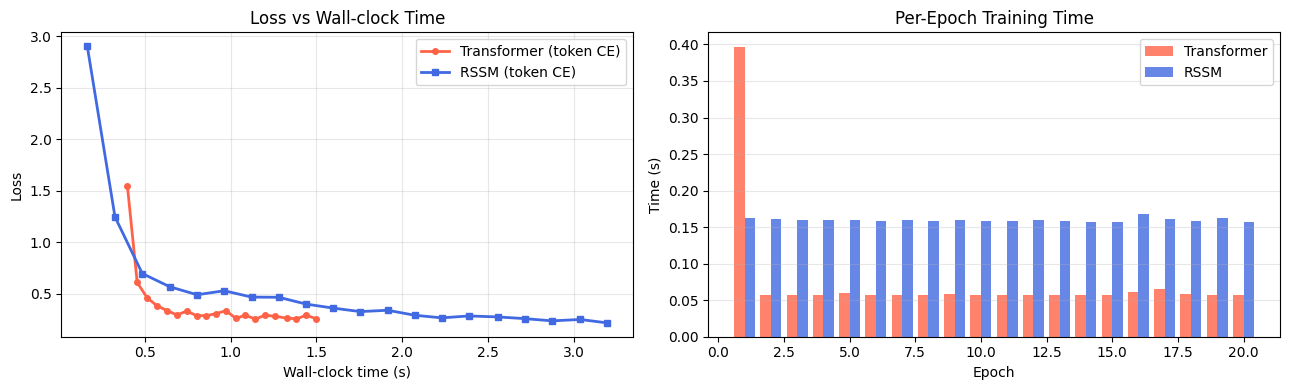

In [17]:
# Plot validation loss vs wall-clock time.
trans_cumtime = np.cumsum(epoch_times)
rssm_cumtime  = np.cumsum(rssm_times)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: loss vs wall-clock time
axes[0].plot(trans_cumtime, token_losses, 'o-', color='tomato',    linewidth=2, markersize=4, label='Transformer (token CE)')
axes[0].plot(rssm_cumtime,  rssm_losses,  's-', color='royalblue', linewidth=2, markersize=4, label='RSSM (token CE)')
axes[0].set_xlabel('Wall-clock time (s)')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss vs Wall-clock Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: per-epoch time bar chart
x = np.arange(1, TRANS_EPOCHS + 1)
axes[1].bar(x - 0.2, epoch_times,  width=0.4, color='tomato',    label='Transformer', alpha=0.8)
axes[1].bar(x + 0.2, rssm_times,   width=0.4, color='royalblue', label='RSSM',        alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Per-Epoch Training Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Architecture Comparison

RSSM and Transformer make different tradeoffs in state representation and compute.

| Property | RSSM (P02) | Causal Transformer (P04) |
|---|---|---|
| **Latent representation** | Continuous Gaussian (deterministic + stochastic) | Discrete categorical (Gumbel-softmax) |
| **Sequence processing** | Sequential GRU, one step at a time | Parallel attention over full context window |
| **Gradient flow** | Through GRU hidden states | Through attention weights |
| **Causal structure** | Implicit in GRU recurrence | Explicit upper-triangular mask |
| **Long-range memory** | Fades with distance (vanishing gradient) | Preserved via attention across all positions |
| **Training parallelism** | Low: must unroll sequentially | High: all positions computed in one forward pass |
| **Parameter count** | Smaller (GRU cell) | Larger (attention layers) |
| **Typical per-epoch time** | Faster on short sequences | Slower but scales better with longer sequences |

The key trade-off is inductive bias vs flexibility. The GRU in RSSM has a built-in notion of recency and smooth latent interpolation, which often helps on short-horizon prediction tasks. The Transformer pays a higher compute cost per step but can attend to any position in the context window equally well, which matters for tasks with long-range dependencies (for example, a door that was opened many steps ago still affects what the agent can do now).

In practice, STORM-style models use the Transformer as the dynamics backbone precisely because it scales more predictably with sequence length and lends itself to token-level reasoning, similar to language models.

In [18]:
# Save model weights.
save_path = PATH / 'transformer_wm.pt'
save_path.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    'catvae': catvae.state_dict(),
    'transformer_wm': transformer_wm.state_dict(),
    'token_losses': token_losses,
    'reward_losses': reward_losses,
    'psnr_rssm': psnr_rssm_mean,
    'psnr_transformer': psnr_trans_mean,
    'horizons': horizons,
}, save_path)

print(f'Saved to {save_path}')
print(f'  CatVAE final recon loss:            {vae_losses[-1]:.4f}')
print(f'  Transformer final token loss:        {token_losses[-1]:.4f}')
print(f'  Transformer final reward loss:       {reward_losses[-1]:.4f}')
print(f'  RSSM PSNR at horizon 10:             {psnr_rssm_mean[-1]:.2f} dB')
print(f'  Transformer PSNR at horizon 10:      {psnr_trans_mean[-1]:.2f} dB')
print(f'  Total Transformer training time:     {trans_cumtime[-1]:.1f}s')
print(f'  Total RSSM training time:            {rssm_cumtime[-1]:.1f}s')

Saved to transformer_wm.pt
  CatVAE final recon loss:            0.0259
  Transformer final token loss:        0.2559
  Transformer final reward loss:       0.1979
  RSSM PSNR at horizon 10:             18.36 dB
  Transformer PSNR at horizon 10:      14.61 dB
  Total Transformer training time:     1.5s
  Total RSSM training time:            3.2s
